## Project 1

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File.

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).

### Part 1: Wrangling and EDA (40/100 pts)

First, go to the NHANES and LMF web sites and familiarize yourself with the data sources. Download codebooks. Think about what resources are available. The CDC Linked Mortality File is somewhat of a pain to work with, so I have pre-cleaned it for you. It is available at httts://github.com/ds4e/undergraduate_ml_assignments in the data folder, as `lmf_parsed.cav`. From the CDC LMF web page, get the SAS program to load the data; it is the real codebook.

Second, download the demographic data for the 1999--2000 wave from the NHANES page. You can use the following code chunk to merge the LMF and DEMO data:

``` python
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
```

Third, the variables `ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` are particularly important. Look them up in the documentation and clearly describe them. (5/100 pts.)

Second, the goal of the project is to use whatever demographic, behavioral, and health data you like to predict mortality (`MORTSTAT`) and life expectancy (`PERMTH_INT`). Go to the NHANES 1999--2000 web page and select your data and download it. Clearly explain your rationale for selecting these data. Use `.merge` to combine your data into one complete dataframe. Document missing values. (5/100 pts)

Third, do basic EDA and visualization of the key variables. Are any important variables skewed? Are there outliers? How correlated are pairs of variables? Do pairs of categorical variables exhibit interesting patterns in contingency tables? Provide a clear discussion and examination of the data and the variables you are interested in using. (20/100 pts)


### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)

**INITIAL DATA MERGING**

In [ ]:
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable

**VARIABLES AND DESCRIPTIONS**



**ELIGSTAT:** Eligibility Status for Mortality (Follow up)
Essentially, this variable tells us whether a person in the survey provided enough information to actually track if they are still alive or have passed away
**Range of Values:** 1(Eligible ), 2(Under age 18, not available for public release),3(Ineligible)


**MORTSTAT:** Final Mortality Status
Tells us the final known death status of the participant at the end of the follow-up period.
**Range of Values:** 0(Assumed alive), 1(Assumed deceased),.(Ineligible or under age 18)


**PERMTH_INT:** Number of Person Months of Follow-up from NHANES interview
date
It tells us exactly how many months a person was "in the study" before the record ended, either because they passed away or because the study reached its cutoff date.
**Range of Values:** 0-374(months) or .(Ineligible or under age 18)


**RIDAGEEX:**
This variable tells us exactly how many months old they were when they actually went to the clinic for their physical exam.
**Range of Values:** 0-1020(months) or if a person was 1020 months or older during the initial interview, the CDC does not provide their age in months.






Source: https://www.cdc.gov/nchs/data/datalinkage/public-use-linked-mortality-files-data-dictionary.pdf


**JOINS BLOOD PRESSURE DATA SET AND HANDLES NULL/UNWANTED VALUES**

**MOTIVATION:** The reason for choosing this variable of interest is because cardio-vascular disease is the leading cause of death in America, and high blood pressure has been proven to increase risk of cardiovascular disease.

In [ ]:

# Load the Blood Pressure Examination data
blood_pressure = pd.read_sas('BPX.xpt')


# Define the columns for each group
systolic_cols = ['BPXSY1', 'BPXSY2', 'BPXSY3']
diastolic_cols = ['BPXDI1', 'BPXDI2', 'BPXDI3']


# Calculate the row-wise mean
# skipna=True (default) ensures that if a person only has 2 readings,
# it averages those 2 rather than returning NaN.
blood_pressure['systolic_avg'] = blood_pressure[systolic_cols].mean(axis=1)
blood_pressure['diastolic_avg'] = blood_pressure[diastolic_cols].mean(axis=1)


# Merge blood pressure data set into original df
df = df.merge(blood_pressure, on="SEQN", how="inner")






# IMPORTANT STEP FOR MISSING VALUES: We found that only 3.62% of adult readings
# were N/A, so we decided to just keep adult readings and drop the remaining
#3.62% of the N/A's

# Filter the dataset to include only adults
df_adults = df[df['RIDAGEEX'] >= 216].copy()

# # Recalculate the percentage of missing values in the blood pressure columns
missing_systolic = df_adults['systolic_avg'].isna().mean() * 100
missing_diastolic = df_adults['diastolic_avg'].isna().mean() * 100

print(f"Missing Systolic (Adults): {missing_systolic:.2f}%")
print(f"Missing Diastolic (Adults): {missing_diastolic:.2f}%")

# Keep only adults (216 months = 18 years)
df_temp = df[df['RIDAGEEX'] >= 216].copy()

# Drop the remaining 3% of rows that have NaNs in BP averages
# This ensures your KNN analysis doesn't crash or encounter errors
df_bp_final = df_temp.dropna(subset=['systolic_avg', 'diastolic_avg'])



df_bp_final.head()



# NOTES:

# BPXSY1, BPXSY2, BPXSY3 (Systolic Blood Pressure): This is the "top number." Medically, elevated systolic pressure is a major risk factor for stroke and heart failure.

# BPXDI1, BPXDI2, BPXDI3 (Diastolic Blood Pressure): The "bottom number." Consistent elevation indicates high pressure in your arteries between heartbeats.

Missing Systolic (Adults): 3.62%
Missing Diastolic (Adults): 3.62%


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,BPXSY3,BPXDI3,BPAEN3,BPXSY4,BPXDI4,BPAEN4,BPXSAR,BPXDAR,systolic_avg,diastolic_avg
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,98.0,56.0,2.0,NaN,NaN,NaN,98.0,56.0,100.666667,56.666667
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,122.0,82.0,2.0,NaN,NaN,NaN,122.0,83.0,122.000000,82.666667
5,6.0,1.0,2.0,2.0,2.0,19.0,230.0,230.0,5.0,4.0,...,112.0,80.0,2.0,NaN,NaN,NaN,114.0,70.0,114.666667,68.000000
6,7.0,1.0,2.0,2.0,2.0,59.0,712.0,712.0,4.0,2.0,...,124.0,82.0,2.0,NaN,NaN,NaN,123.0,81.0,125.333333,80.000000
9,10.0,1.0,2.0,2.0,1.0,43.0,518.0,518.0,4.0,2.0,...,142.0,96.0,2.0,NaN,NaN,NaN,142.0,95.0,145.333333,96.000000


Source: https://wwwn.cdc.gov/nchs/nhanes/search/datapage.aspx?Component=Examination&Cycle=1999-2000

**JOINS SMOKING DATA SET AND HANDLES NULL/UNWANTED VALUES**

**MOTIVATION:** Blood pressure can be heavily influenced by lifestyle factors, most notably tobacco use. Smoking acts as a significant catalyst for cardiovascular decline by causing immediate spikes in blood pressure and long-term arterial damage.

In [ ]:
import numpy as np

# Load the Blood Pressure Examination data
smoking_status = pd.read_sas('SMQ.xpt')

df_bp_final = df_bp_final.merge(smoking_status, on="SEQN", how="inner")

df_bp_final.head()



import numpy as np

# Initial cleaning as per your current code
df_bp_final['SMD030'] = df_bp_final['SMD030'].replace([777, 999, 7777, 9999], np.nan)
df_bp_final['SMD030'] = df_bp_final['SMD030'].fillna(df_bp_final['SMD030'].median())

# Fill missing values with 0 for logic processing
cols_to_fix = ['SMD030', 'SMD055', 'SMD070']
df_bp_final[cols_to_fix] = df_bp_final[cols_to_fix].fillna(0)

def calculate_pack_years(row):
    # Logic for Never-Smokers
    if row['SMD030'] == 0:
        return 0, 0

    # Logic for Current Smokers (SMQ040 codes 1 or 2)
    # They haven't stopped, so 'years smoked' = Current Age - Age Started
    if row['SMQ040'] in [1, 2]:
        years = max(0, row['RIDAGEYR'] - row['SMD030'])
    # Logic for Former Smokers
    # 'years smoked' = Age Stopped - Age Started
    else:
        years = max(0, row['SMD055'] - row['SMD030'])

    # Final Pack-Year Calculation: (Cigs per day / 20) * Years
    pack_years = (row['SMD070'] / 20) * years
    return years, pack_years

# Apply the function to create two new columns
df_bp_final[['years_smoked', 'pack_years']] = df_bp_final.apply(
    lambda row: pd.Series(calculate_pack_years(row)), axis=1
)








Source: https://wwwn.cdc.gov/nchs/nhanes/search/datapage.aspx?Component=Questionnaire&Cycle=1999-2000

**EDA**

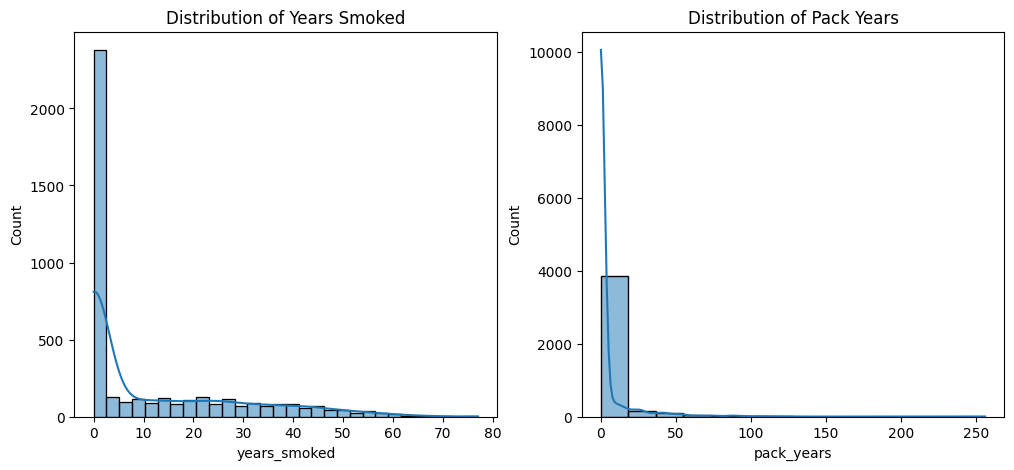

years_smoked    1.349558
pack_years      5.824569
PERMTH_INT     -1.728693
dtype: float64
log_pack_years      2.286123
log_years_smoked    0.500961
dtype: float64


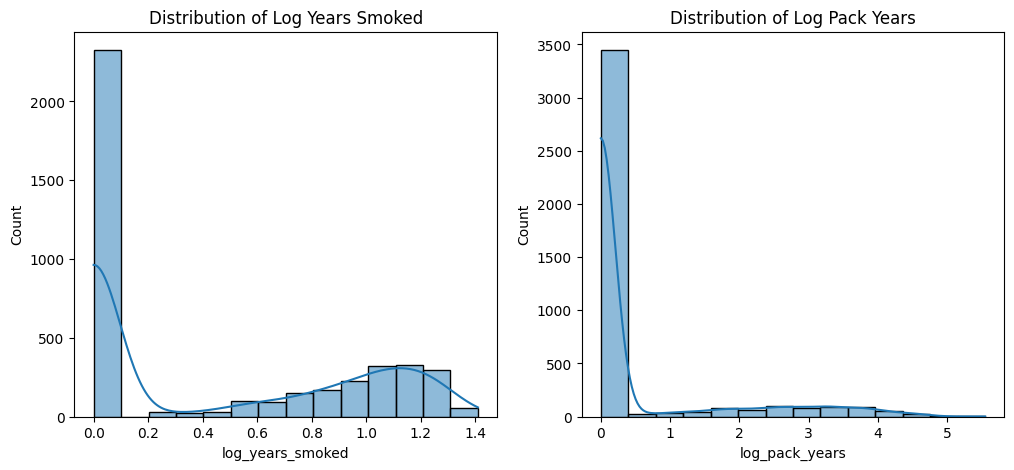

log_years_smoked    0.500961
log_pack_years      2.286123
PERMTH_INT         -1.728693
dtype: float64


In [ ]:
# CHECK FOR SKEWEDNESS

import seaborn as sns
import matplotlib.pyplot as plt




# INITIAL SKEW

# 1. Distribution and Skewness
# Visualizing distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_bp_final['years_smoked'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Years Smoked')

sns.histplot(df_bp_final['pack_years'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Pack Years')

plt.show()

# Check numerical skewness (Values > 1 indicate high skew)
print(df_bp_final[['years_smoked', 'pack_years', 'PERMTH_INT']].skew())





#------------------------------------------------------------------------------------------------------------------------

# FIX!




# FILTERING

# Cap years_smoked at a reasonable human limit (e.g., 90 years)
# and pack_years at a reasonable max (e.g., 150-200)
df_bp_final = df_bp_final[df_bp_final['years_smoked'] < 100]
df_bp_final = df_bp_final[df_bp_final['pack_years'] < 300]





# LOG TRANSFORMATION

# Add 1 because log(0) is undefined
df_bp_final['log_pack_years'] = np.log1p(df_bp_final['pack_years'])
df_bp_final['log_years_smoked'] = np.log1p(df_bp_final['years_smoked'])

print(df_bp_final[['log_pack_years', 'log_years_smoked']].skew())




# ROBUST SCALING

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
# Scale your features before putting them into the KNN
cols_to_scale = ['log_pack_years', 'log_years_smoked', 'RIDAGEYR']
df_bp_final[cols_to_scale] = scaler.fit_transform(df_bp_final[cols_to_scale])





#------------------------------------------------------------------------------------------------------------------------


# RESULTS!


# 1. Distribution and Skewness
# Visualizing distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_bp_final['log_years_smoked'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Log Years Smoked')

sns.histplot(df_bp_final['log_pack_years'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Log Pack Years')

plt.show()

# Check numerical skewness (Values > 1 indicate high skew)
print(df_bp_final[['log_years_smoked', 'log_pack_years', 'PERMTH_INT']].skew())








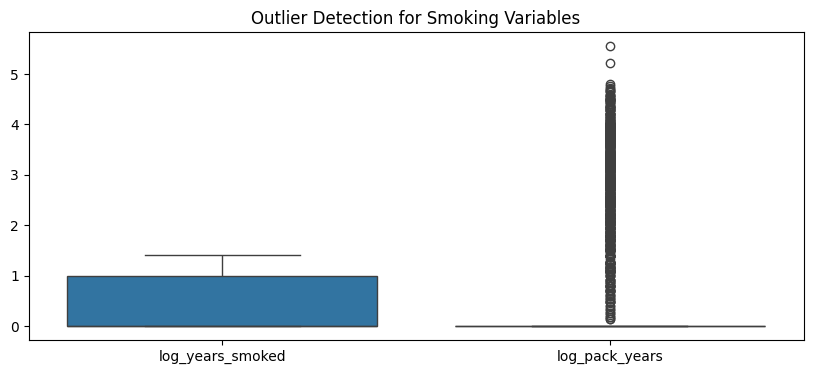

In [ ]:
# BOXPLOT FOR OUTLIERS


plt.figure(figsize=(10, 4))
sns.boxplot(data=df_bp_final[['log_years_smoked', 'log_pack_years']])
plt.title('Outlier Detection for Smoking Variables')
plt.show()


# We must move forth with caution and ackowledge that KNN might not be as robust
# at classifying light and heavy smokers compared to non-smokers

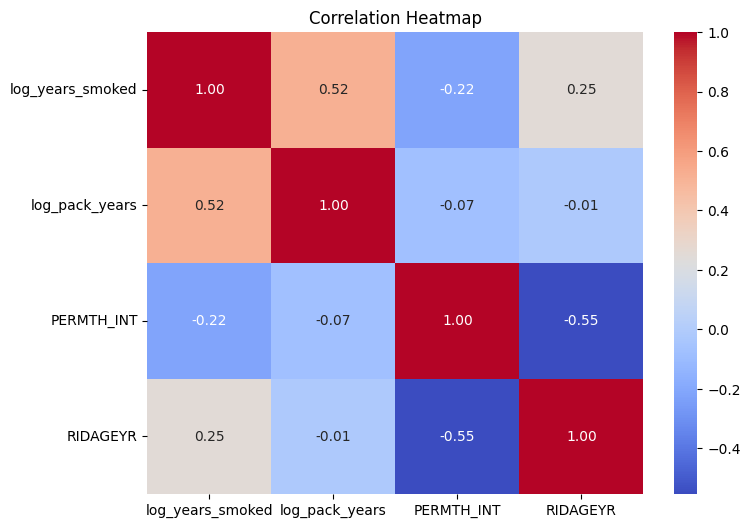

In [ ]:
# CORRELATION ANALYSIS

corr_matrix = df_bp_final[['log_years_smoked', 'log_pack_years', 'PERMTH_INT', 'RIDAGEYR']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()



# We will consider running our model twice (once with each variable in order to
# see which is a better predictor of MORTSTAT).

**Final Discussion for EDA:**

**Outliers:** We initially removed extreme values (e.g., years > 100), but significant outliers remain in pack_years due to heavy smokers. These were managed using a log transformation

**Distribution:** The data is highly zero-inflated, as 75% of participants have 0 pack-years. This creates a dense cluster at the origin of our feature space.

**Feature Choice:** Despite the 0.52 correlation between smoking variables, we retained both to see if years_smoked or pack_years provide a more distinct signal for mortality prediction.

Code Source: Gemini